# Loan Approval Prediction

## Project Overview

This project develops a machine learning classification system to predict whether a loan application should be approved or rejected based on applicant, financial, and credit-related characteristics.

The project follows an end-to-end machine learning workflow, including:

- Data understanding and quality assessment
- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Feature engineering
- Class imbalance analysis and handling
- Model training
- Hyperparameter tuning
- Model evaluation
- Model comparison
- Feature importance and model interpretation
- Final model selection

### Models

Three classification algorithms are evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

The final objective is to identify the best-performing model based on multiple evaluation metrics rather than accuracy alone.

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
RANDOM_STATE = 42
TEST_SIZE = 0.20
sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
DATA_PATH = "../data/loan_approval_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


## 3. Initial Dataset Overview

In [5]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Number of rows: 4,269
Number of columns: 13


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## 4. Statistical Overview

In [10]:
#numerical
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [11]:
#categorical
df.describe(include="object").T

,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656


## 5. Data Quality Assessment

### 5.1 Missing Values

In [14]:
missing = df.isnull().sum()
print("Missing values : ", missing)

Missing values :  loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


### 5.2 Duplicate Records

In [15]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


### 5.3 Unique Values

The number of unique values in each feature is examined to identify categorical variables, identifier-like columns, and potentially unusual features.

In [16]:
unique_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

unique_summary.sort_values("Unique Values")

,Data Type,Unique Values,Missing Values
self_employed,object,2,0
education,object,2,0
loan_status,object,2,0
no_of_dependents,int64,6,0
loan_term,int64,10,0
income_annum,int64,98,0
bank_asset_value,int64,146,0
commercial_assets_value,int64,188,0
residential_assets_value,int64,278,0
loan_amount,int64,378,0


## 6. Feature Type Analysis

Features are separated into numerical and categorical variables. This distinction is important because the two feature types require different preprocessing techniques.

In [17]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']

Categorical Features:
[' education', ' self_employed', ' loan_status']


In [18]:
print(f"Number of numerical features: {len(numerical_columns)}")
print(f"Number of categorical features: {len(categorical_columns)}")

Number of numerical features: 10
Number of categorical features: 3


In [20]:
for col in categorical_columns:
    print(f"{col}")
    print(f"{'=' * 60}")
    print(df[col].value_counts(dropna=False))

 education
 education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
 self_employed
 self_employed
Yes    2150
No     2119
Name: count, dtype: int64
 loan_status
 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


### Target Setting

In [30]:
df.columns = df.columns.str.strip()

In [31]:
for col in df.columns:
    print(repr(col))

'loan_id'
'no_of_dependents'
'education'
'self_employed'
'income_annum'
'loan_amount'
'loan_term'
'cibil_score'
'residential_assets_value'
'commercial_assets_value'
'luxury_assets_value'
'bank_asset_value'
'loan_status'


In [32]:
TARGET = "loan_status"

In [33]:
print("Target column:", TARGET)
print("\nTarget distribution:")
print(df[TARGET].value_counts())

Target column: loan_status

Target distribution:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [34]:
target_distribution = pd.DataFrame({
    "Count": df[TARGET].value_counts(dropna=False),
    "Percentage": df[TARGET].value_counts(
        normalize=True,
        dropna=False
    ) * 100
})

target_distribution

,Count,Percentage
loan_status,,
Approved,2656,62.215976
Rejected,1613,37.784024


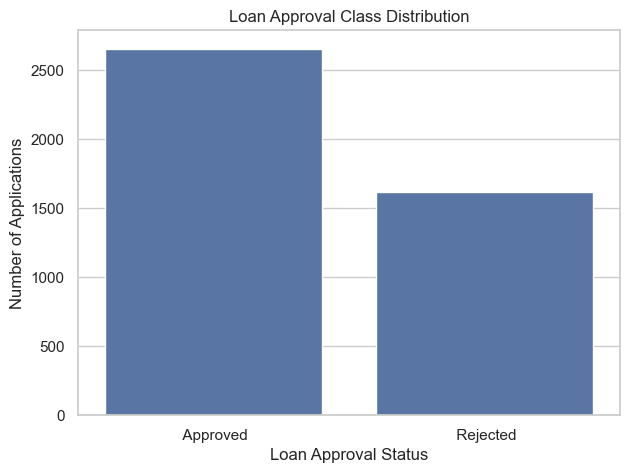

In [35]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Approval Status")
plt.ylabel("Number of Applications")

plt.show()